# DD-ME2 equation of state — beta-equilibrated nucleonic matter (v2)

This is the cleaned-up version incorporating what we worked through step by
step: the effective mass $M^*$ is solved **directly** (one implicit equation,
one unknown) instead of solving for $\sigma$ first and converting — the two
are mathematically identical, this is just fewer moving parts. The $\omega$
and $\rho$ field equations are written as an explicit sum over baryon species
(currently just n, p) so the code is ready to extend to hyperons later.

**Equations used, cell by cell:**
1. constants + DD-ME2 parameters (Table I)
2. density-dependent couplings $g_i(\rho_B)$ — Eqs. (7)-(9)
3. closed-form scalar density / kinetic energy / kinetic pressure (from the
   $\rho_{s,B}=\sum_B\frac{2J_B+1}{2\pi^2}\int_0^{k_B}\frac{m^*_B}{\sqrt{k^2+m_B^{*2}}}k^2\,dk$
   integral, verified against direct numerical integration)
4. self-consistent effective-mass solve: $M^* = M - \dfrac{g_\sigma^2}{m_\sigma^2}\rho_s(M^*)$
5. baryon species list + $\omega_0=\sum_B\frac{g_{\omega B}}{m_\omega^2}\rho_B$,
   $\rho_{03}=\sum_B\frac{g_{\rho B}}{m_\rho^2}I_{3B}\rho_B$
6. charge neutrality + $\beta$-equilibrium solve for the proton fraction
7. energy density (Eq. 3) split into its three labeled groups; pressure with
   the rearrangement term (Eqs. 10-11)
8. loop over $n_B$, build the EoS table
9. particle fractions $y_p, y_n, y_e$ vs $\rho_B/\rho_0$
10. plots: $\rho_B/\rho_0$ vs $P$, $\rho_B/\rho_0$ vs $\varepsilon$, $P$ vs $\varepsilon$
11. verification: numeric-integral check + thermodynamic-consistency check
12. compare against a reference DD-ME2 dataset


## 1. Constants and DD-ME2 parameters (Table I)

In [1]:

import numpy as np
from scipy.optimize import brentq
from scipy.integrate import quad
import matplotlib.pyplot as plt
import pandas as pd

# ---- physical constants ----
hbarc = 197.32696          # MeV*fm

M    = 939.0                # nucleon mass [MeV]
m_e  = 0.511                # electron mass [MeV]
m_mu = 105.658               # muon mass [MeV]

rho0 = 0.152                 # nuclear saturation density [fm^-3] (paper, Fig. 1 caption)

# ---- DD-ME2 meson masses and couplings at saturation, Table I ----
m_sigma = 550.1238           # MeV
m_omega = 783.0000
m_rho   = 763.0000

g_sigma0 = 10.5396
g_omega0 = 13.0189
g_rho0   = 3.6836

# h_i(x) parameters (sigma, omega only)
a_s, b_s, c_s, d_s = 1.3881, 1.0943, 1.7057, 0.4421
a_w, b_w, c_w, d_w = 1.3892, 0.9240, 1.4620, 0.4775

# rho meson: exponential ansatz instead of h_i(x)
a_r = 0.5647


## 2. Density-dependent couplings — Eqs. (7)-(9)

$$g_i(\rho_B)=g_i(\rho_0)\,h_i(x),\quad x=\rho_B/\rho_0,\quad i=\sigma,\omega,
\qquad h_i(x)=a_i\frac{1+b_i(x+d_i)^2}{1+c_i(x+d_i)^2}$$
$$g_\rho(\rho_B)=g_\rho(\rho_0)\exp[-a_\rho(x-1)]$$


In [2]:

def h(x, a, b, c, d):
    u = x + d
    return a * (1.0 + b*u**2) / (1.0 + c*u**2)

def dh_dx(x, a, b, c, d):
    # analytic derivative of h_i(x) -- used later for the rearrangement term
    u = x + d
    return 2.0*a*u*(b - c) / (1.0 + c*u**2)**2

def g_sigma(rhoB):
    return g_sigma0 * h(rhoB/rho0, a_s, b_s, c_s, d_s)

def g_omega(rhoB):
    return g_omega0 * h(rhoB/rho0, a_w, b_w, c_w, d_w)

def g_rho(rhoB):
    return g_rho0 * np.exp(-a_r*(rhoB/rho0 - 1.0))

def dgsigma_drho(rhoB):
    return g_sigma0 * dh_dx(rhoB/rho0, a_s, b_s, c_s, d_s) / rho0

def dgomega_drho(rhoB):
    return g_omega0 * dh_dx(rhoB/rho0, a_w, b_w, c_w, d_w) / rho0


## 3. Fermi-gas kinematics and closed-form (T = 0) integrals

$$\rho_s=\frac{M^{*3}}{2\pi^2}\Big[q\sqrt{1+q^2}-\ln(q+\sqrt{1+q^2})\Big],\quad q=k_F/M^*$$
$$\varepsilon_{\rm kin}=\frac{M^{*4}}{8\pi^2}\Big[q(1+2q^2)\sqrt{1+q^2}-\ln(q+\sqrt{1+q^2})\Big]$$
$$P_{\rm kin}=\frac{M^{*4}}{24\pi^2}\Big[q(2q^2-3)\sqrt{1+q^2}+3\ln(q+\sqrt{1+q^2})\Big]$$

These are the analytic evaluations of the Fermi-sea integrals (the
$\rho_{s,B}$ one is checked against a raw numerical integration in the last
cell of this notebook).


In [3]:

def kF_of_n(n_fm3):
    if n_fm3 <= 0.0:
        return 0.0
    n_MeV3 = n_fm3 * hbarc**3
    return (3.0*np.pi**2 * n_MeV3)**(1.0/3.0)

def n_of_kF(kF_MeV):
    return kF_MeV**3 / (3.0*np.pi**2) / hbarc**3

def scalar_density(kF, Mstar):
    if kF <= 0.0 or Mstar <= 0.0:
        return 0.0
    q = kF/Mstar
    val = (Mstar**3/(2.0*np.pi**2)) * (q*np.sqrt(1.0+q**2) - np.log(q+np.sqrt(1.0+q**2)))
    return val / hbarc**3

def energy_density_kin(kF, Mstar):
    if kF <= 0.0 or Mstar <= 0.0:
        return 0.0
    q = kF/Mstar
    val = (Mstar**4/(8.0*np.pi**2)) * (q*(1.0+2.0*q**2)*np.sqrt(1.0+q**2) - np.log(q+np.sqrt(1.0+q**2)))
    return val / hbarc**3

def pressure_kin(kF, Mstar):
    if kF <= 0.0 or Mstar <= 0.0:
        return 0.0
    q = kF/Mstar
    val = (Mstar**4/(24.0*np.pi**2)) * (q*(2.0*q**2-3.0)*np.sqrt(1.0+q**2) + 3.0*np.log(q+np.sqrt(1.0+q**2)))
    return val / hbarc**3


## 4. Self-consistent effective mass -- solved directly

Instead of solving $m_\sigma^2\sigma=g_\sigma\rho_s(\sigma)$ for $\sigma$ and
then converting to $M^*=M-g_\sigma\sigma$, substitute $\sigma=g_\sigma\rho_s/m_\sigma^2$
straight into the mass formula:

$$M^* = M - \frac{g_\sigma^2}{m_\sigma^2}\,\rho_s(M^*)$$

This is still implicit ($M^*$ sits on both sides, since $\rho_s$ is itself a
function of $M^*$), so it still needs a root-find -- but now it's one
equation in one unknown ($M^*$) instead of bouncing between $\sigma$ and
$M^*$. $\sigma$ itself is recovered afterwards, only when needed for the
meson-field energy term, via $\sigma=(M-M^*)/g_\sigma$.


In [4]:

def solve_Mstar(n_p, n_n):
    rhoB = n_p + n_n
    gs = g_sigma(rhoB)
    kFp = kF_of_n(n_p)
    kFn = kF_of_n(n_n)

    def F(Mstar):
        rho_s = scalar_density(kFp, Mstar) + scalar_density(kFn, Mstar)
        return Mstar - M + (gs**2/m_sigma**2) * rho_s * hbarc**3

    return brentq(F, 1e-6, M, xtol=1e-12, rtol=1e-13)

def sigma_from_Mstar(Mstar, rhoB):
    gs = g_sigma(rhoB)
    return (M - Mstar) / gs


## 5. Baryon species list, and the $\omega$ / $\rho$ field sums

$$\omega_0=\sum_B \frac{g_{\omega B}}{m_\omega^2}\rho_B, \qquad
\rho_{03}=\sum_B \frac{g_{\rho B}}{m_\rho^2} I_{3B}\,\rho_B$$

Written here as an explicit loop over a species list (currently just proton
and neutron, both with the same nucleon couplings $g_{\omega N},g_{\rho N}$)
so this is a one-line change away from adding hyperons later.


In [5]:

# species: name, isospin projection I3
BARYON_SPECIES = [
    {"name": "p", "I3": +0.5},
    {"name": "n", "I3": -0.5},
]

def omega_field(densities, rhoB):
    # densities: dict {species_name: number_density [fm^-3]}
    gw = g_omega(rhoB)          # same coupling for p and n (isoscalar)
    total = sum(gw * densities[s["name"]] for s in BARYON_SPECIES)
    return total * hbarc**3 / m_omega**2

def rho_field(densities, rhoB):
    gr = g_rho(rhoB)            # same coupling for p and n
    total = sum(gr * s["I3"] * densities[s["name"]] for s in BARYON_SPECIES)
    return total * hbarc**3 / m_rho**2


## 6. Charge neutrality + $\beta$-equilibrium

Find the proton fraction $y_p$ such that $n_p=n_e+n_\mu$, with
$\mu_e=(E_F^n-E_F^p)-g_\rho\rho_{03}$ (from $\mu_n=\mu_p+\mu_e$, $\mu_\mu=\mu_e$).


In [6]:

def net_charge(y_p, n_B):
    n_p = y_p * n_B
    n_n = (1.0 - y_p) * n_B
    densities = {"p": n_p, "n": n_n}
    rhoB = n_B

    Mstar = solve_Mstar(n_p, n_n)

    kFp = kF_of_n(n_p)
    kFn = kF_of_n(n_n)
    EFp = np.sqrt(kFp**2 + Mstar**2)
    EFn = np.sqrt(kFn**2 + Mstar**2)

    gr = g_rho(rhoB)
    rho03 = rho_field(densities, rhoB)

    mu_e = (EFn - EFp) - gr*rho03

    n_e = n_of_kF(np.sqrt(mu_e**2 - m_e**2)) if mu_e > m_e else 0.0
    n_mu = n_of_kF(np.sqrt(mu_e**2 - m_mu**2)) if mu_e > m_mu else 0.0

    return n_p - (n_e + n_mu)


def solve_composition(n_B):
    ys = np.linspace(1e-6, 0.6, 60)
    vals = [net_charge(y, n_B) for y in ys]
    y_lo = y_hi = None
    for i in range(len(ys)-1):
        if vals[i] == 0.0:
            y_lo = y_hi = ys[i]
            break
        if vals[i]*vals[i+1] < 0.0:
            y_lo, y_hi = ys[i], ys[i+1]
            break
    if y_lo is None:
        raise RuntimeError(f"no charge-neutral solution bracket found at n_B={n_B}")
    if y_lo == y_hi:
        return y_lo
    return brentq(net_charge, y_lo, y_hi, args=(n_B,), xtol=1e-12)


## 7. Energy density and pressure -- Eq. (3), Eqs. (10)-(11)

$\varepsilon$ splits into exactly the three groups we walked through:

- **meson-field terms** (3 constants $m_\sigma,m_\omega,m_\rho$ x 3 solved
  fields $\sigma,\omega_0,\rho_{03}$)
- **baryon kinetic terms**, one per species, using the shared $M^*$ and each
  species' own $k_F$
- **lepton kinetic terms**, same formula, but with the real lepton mass and
  the lepton's own $k_F$

Pressure needs one extra piece, the rearrangement term $\Sigma_r$, which
enters $P$ only -- never $\varepsilon$.


In [7]:

def eos_point(n_B):
    y_p = solve_composition(n_B)
    n_p = y_p * n_B
    n_n = (1.0 - y_p) * n_B
    densities = {"p": n_p, "n": n_n}
    rhoB = n_B

    Mstar = solve_Mstar(n_p, n_n)
    sigma = sigma_from_Mstar(Mstar, rhoB)
    omega0 = omega_field(densities, rhoB)
    rho03  = rho_field(densities, rhoB)

    kFp = kF_of_n(n_p)
    kFn = kF_of_n(n_n)
    EFp = np.sqrt(kFp**2 + Mstar**2)
    EFn = np.sqrt(kFn**2 + Mstar**2)

    gr = g_rho(rhoB)
    mu_e = (EFn - EFp) - gr*rho03
    kFe  = np.sqrt(mu_e**2 - m_e**2)  if mu_e > m_e  else 0.0
    kFmu = np.sqrt(mu_e**2 - m_mu**2) if mu_e > m_mu else 0.0

    # ---- Group 1: meson-field energy ----
    eps_meson = 0.5*m_sigma**2*sigma**2/hbarc**3 \
              + 0.5*m_omega**2*omega0**2/hbarc**3 \
              + 0.5*m_rho**2*rho03**2/hbarc**3

    # ---- Group 2: baryon kinetic energy, summed over species ----
    eps_baryon = sum(energy_density_kin(kF_of_n(densities[s["name"]]), Mstar)
                      for s in BARYON_SPECIES)

    # ---- Group 3: lepton kinetic energy ----
    eps_lepton = energy_density_kin(kFe, m_e) + energy_density_kin(kFmu, m_mu)

    epsilon = eps_meson + eps_baryon + eps_lepton

    # ---- pressure: same three groups (sign flip on meson-sigma term) + rearrangement ----
    rho_S = sum(scalar_density(kF_of_n(densities[s["name"]]), Mstar) for s in BARYON_SPECIES)
    Sigma_r = dgomega_drho(rhoB)*omega0*rhoB - dgsigma_drho(rhoB)*sigma*rho_S

    P_meson  = -0.5*m_sigma**2*sigma**2/hbarc**3 \
             + 0.5*m_omega**2*omega0**2/hbarc**3 \
             + 0.5*m_rho**2*rho03**2/hbarc**3
    P_baryon = sum(pressure_kin(kF_of_n(densities[s["name"]]), Mstar) for s in BARYON_SPECIES)
    P_lepton = pressure_kin(kFe, m_e) + pressure_kin(kFmu, m_mu)
    pressure = P_meson + P_baryon + P_lepton + rhoB*Sigma_r

    return epsilon, pressure, y_p, Mstar/M


## 8. Loop over a range of $n_B$ to build the EoS table

In [8]:

n_values = np.linspace(0.02, 6.0*rho0, 80)

rows = []
for n_B in n_values:
    eps, P, y_p, Mratio = eos_point(n_B)
    rows.append((n_B, n_B/rho0, eps, P, y_p, Mratio))

df = pd.DataFrame(rows, columns=["n_B[fm^-3]", "rhoB/rho0", "epsilon[MeV/fm^3]",
                                  "P[MeV/fm^3]", "y_p", "Mstar/M"])
df.to_csv("ddme2_eos_v2.csv", index=False)
df.head()


,n_B[fm^-3],rhoB/rho0,epsilon[MeV/fm^3],P[MeV/fm^3],y_p,Mstar/M
0,0.020000,0.131579,18.791327,-0.017059,0.001854,0.913129
1,0.031291,0.205863,29.384778,-0.020374,0.003282,0.871136
2,0.042582,0.280147,39.977333,0.008151,0.004858,0.833349
3,0.053873,0.354430,50.577230,0.078533,0.006535,0.799083
4,0.065165,0.428714,61.190569,0.195139,0.008287,0.767720


## 9. Particle fractions $y_p$, $y_n$, $y_e$

Before looking at $P$, it helps to see *what the matter is made of* at each
density: $y_i = n_i/n_B$ for protons, neutrons, and electrons (the same
composition that came out of the charge-neutrality + $\beta$-equilibrium
solve in step 6, just read back out and plotted).


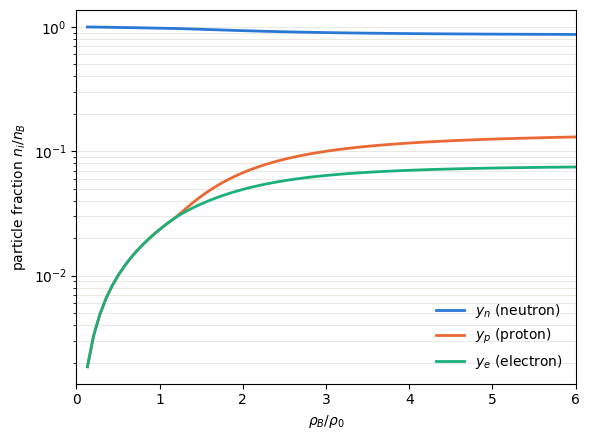

In [9]:

def lepton_fraction_e(n_B, y_p):
    # electron number fraction n_e/n_B for a given total density and proton fraction
    n_p = y_p * n_B
    n_n = (1.0 - y_p) * n_B
    rhoB = n_B

    Mstar = solve_Mstar(n_p, n_n)
    kFp = kF_of_n(n_p)
    kFn = kF_of_n(n_n)
    EFp = np.sqrt(kFp**2 + Mstar**2)
    EFn = np.sqrt(kFn**2 + Mstar**2)

    gr = g_rho(rhoB)
    rho03 = (gr/2.0) * (n_p - n_n) * hbarc**3 / m_rho**2
    mu_e = (EFn - EFp) - gr*rho03

    n_e = n_of_kF(np.sqrt(mu_e**2 - m_e**2)) if mu_e > m_e else 0.0
    return n_e / n_B


x_arr = df["rhoB/rho0"].values
y_p_arr = df["y_p"].values
y_n_arr = 1.0 - y_p_arr
y_e_arr = np.array([lepton_fraction_e(nB, yp) for nB, yp in zip(n_values, y_p_arr)])

blue, orange, aqua = '#2a78d6', '#eb6834', '#1baf7a'

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(x_arr, y_n_arr, color=blue,   linewidth=2, label=r'$y_n$ (neutron)')
ax.plot(x_arr, y_p_arr, color=orange, linewidth=2, label=r'$y_p$ (proton)')
ax.plot(x_arr, y_e_arr, color=aqua,   linewidth=2, label=r'$y_e$ (electron)')
ax.set_yscale('log')
ax.set_xlabel(r'$\rho_B/\rho_0$')
ax.set_ylabel(r'particle fraction $n_i/n_B$')
ax.set_xlim(0, 6)
ax.grid(axis='y', color='#e9e8e1', linewidth=0.7, which='both')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 10. Plots

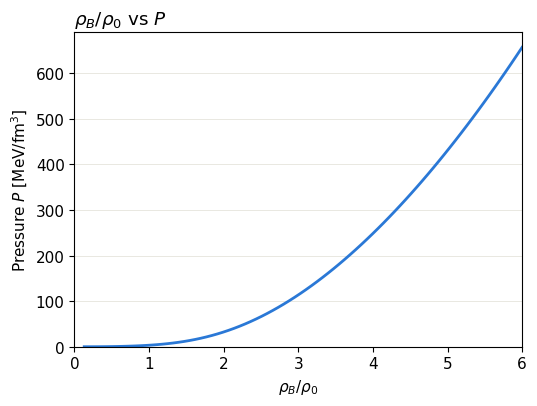

In [10]:

blue = '#2a78d6'
plt.rcParams.update({'font.size': 11})
x_arr   = df["rhoB/rho0"].values
eps_arr = df["epsilon[MeV/fm^3]"].values
P_arr   = df["P[MeV/fm^3]"].values

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.plot(x_arr, P_arr, color=blue, linewidth=2)
ax.set_xlabel(r'$\rho_B/\rho_0$'); ax.set_ylabel(r'Pressure $P$ [MeV/fm$^3$]')
ax.set_title(r'$\rho_B/\rho_0$ vs $P$', loc='left')
ax.set_xlim(0, 6); ax.set_ylim(bottom=0)
ax.grid(axis='y', color='#e9e8e1', linewidth=0.7)
plt.tight_layout(); plt.show()


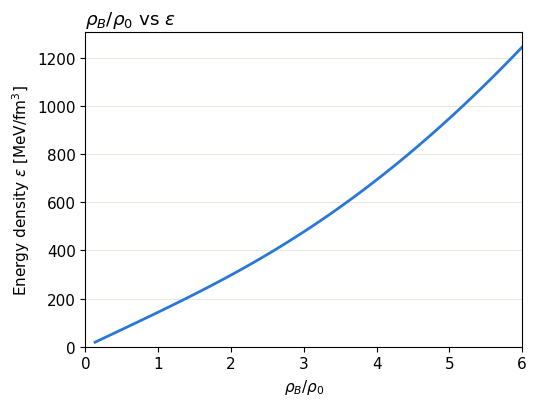

In [11]:

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.plot(x_arr, eps_arr, color=blue, linewidth=2)
ax.set_xlabel(r'$\rho_B/\rho_0$'); ax.set_ylabel(r'Energy density $\varepsilon$ [MeV/fm$^3$]')
ax.set_title(r'$\rho_B/\rho_0$ vs $\varepsilon$', loc='left')
ax.set_xlim(0, 6); ax.set_ylim(bottom=0)
ax.grid(axis='y', color='#e9e8e1', linewidth=0.7)
plt.tight_layout(); plt.show()


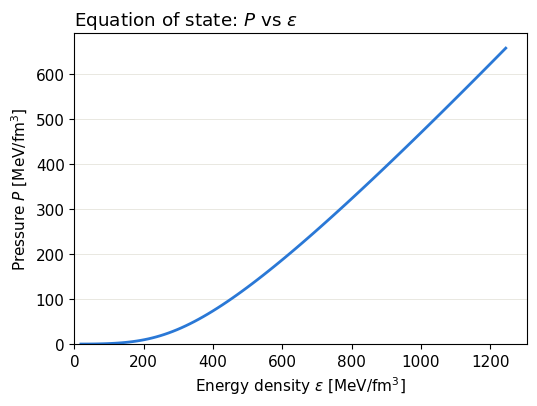

In [12]:

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.plot(eps_arr, P_arr, color=blue, linewidth=2)
ax.set_xlabel(r'Energy density $\varepsilon$ [MeV/fm$^3$]'); ax.set_ylabel(r'Pressure $P$ [MeV/fm$^3$]')
ax.set_title(r'Equation of state: $P$ vs $\varepsilon$', loc='left')
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.grid(axis='y', color='#e9e8e1', linewidth=0.7)
plt.tight_layout(); plt.show()


## 11. Verification

Two independent checks:

1. The closed-form $\rho_s$ formula must match a raw numerical integration of
   $\rho_{s,B}=\frac{2J_B+1}{2\pi^2}\int_0^{k_F}\frac{M^*k^2}{\sqrt{k^2+M^{*2}}}dk$.
2. The thermodynamic identity $d\varepsilon/dn_B = (\varepsilon+P)/n_B$ must hold
   (this is only exactly true if $\varepsilon$ and $P$, including the
   rearrangement term, are mutually consistent).


In [13]:

# ---- check 1: closed form vs raw numerical integral ----
Mstar_test, kF_test = 500.0, 300.0
integrand = lambda k: (Mstar_test/np.sqrt(k**2+Mstar_test**2)) * k**2
integral_val, _ = quad(integrand, 0, kF_test)
rho_s_numeric = 2.0/(2*np.pi**2) * integral_val          # gamma = 2J+1 = 2
rho_s_closed  = scalar_density(kF_test, Mstar_test) * hbarc**3   # back to MeV^3 for comparison

print("rho_s: numeric integral =", rho_s_numeric)
print("rho_s: closed form      =", rho_s_closed)
print("relative difference     =", abs(rho_s_numeric-rho_s_closed)/rho_s_closed)

# ---- check 2: thermodynamic consistency ----
deps_dn = np.gradient(eps_arr, n_values)
mu_thermo = (eps_arr + P_arr) / n_values
rel_mismatch = np.abs(deps_dn - mu_thermo) / mu_thermo
print("\nmax relative mismatch in d(eps)/d(nB) vs (eps+P)/nB:",
      f"{rel_mismatch[5:-5].max()*100:.3f} %")


rho_s: numeric integral = 828866.3565554209
rho_s: closed form      = 828866.3565554204
relative difference     = 5.61805028790071e-16

max relative mismatch in d(eps)/d(nB) vs (eps+P)/nB: 0.397 %


## 12. Compare against a reference DD-ME2 dataset

Loads an external reference table (`DDME2_neutrino.xlsx`, expected in the
same folder as this notebook) with columns `nb/n0`, `nb(1/fm3)`,
`eng(MeV/fm^3)`, `Prs(MeV/fm^3)`, ... and evaluates our own `eos_point()`
at the *same* $n_B$ values the reference table uses, so the two can be
compared point by point rather than on two different density grids.

Only the density range the two have in common is used (our own grid here
covers up to $6\rho_0$; the reference table's densities below that cap are
kept, higher ones dropped).


In [14]:

ref = pd.read_excel("DDME2_neutrino.xlsx", sheet_name="Sheet1")
ref = ref.rename(columns={
    ref.columns[0]: "x_ref",       # nb/n0
    ref.columns[1]: "nB_ref",      # fm^-3
    ref.columns[2]: "eps_ref",     # MeV/fm^3
    ref.columns[3]: "P_ref",       # MeV/fm^3
})

# keep only the density range our own grid also covers
ref = ref[ref["nB_ref"] <= n_values.max()].reset_index(drop=True)

comp_rows = []
for _, row in ref.iterrows():
    eps_th, P_th, y_p_th, Mratio_th = eos_point(row["nB_ref"])
    comp_rows.append((row["x_ref"], row["nB_ref"],
                       row["eps_ref"], eps_th,
                       row["P_ref"], P_th))

comp = pd.DataFrame(comp_rows, columns=["rhoB/rho0", "nB[fm^-3]",
                                         "eps_ref", "eps_theory",
                                         "P_ref", "P_theory"])
comp["eps_reldiff_%"] = 100*(comp["eps_theory"]-comp["eps_ref"])/comp["eps_ref"]
comp["P_reldiff_%"]   = 100*(comp["P_theory"]-comp["P_ref"])/comp["P_ref"]

print(f"compared at {len(comp)} density points, "
      f"rhoB/rho0 in [{comp['rhoB/rho0'].min():.2f}, {comp['rhoB/rho0'].max():.2f}]")
print(f"energy density: mean |reldiff| = {comp['eps_reldiff_%'].abs().mean():.2f} %, "
      f"max |reldiff| = {comp['eps_reldiff_%'].abs().max():.2f} %")
print(f"pressure      : mean |reldiff| = {comp['P_reldiff_%'].abs().mean():.2f} %, "
      f"max |reldiff| = {comp['P_reldiff_%'].abs().max():.2f} %")

comp.to_csv("ddme2_vs_reference.csv", index=False)
comp.head()


compared at 1233 density points, rhoB/rho0 in [0.51, 5.99]
energy density: mean |reldiff| = 1.33 %, max |reldiff| = 1.74 %
pressure      : mean |reldiff| = 15.28 %, max |reldiff| = 39.28 %


,rhoB/rho0,nB[fm^-3],eps_ref,eps_theory,P_ref,P_theory,eps_reldiff_%,P_reldiff_%
0,0.510000,0.077520,74.0584,72.825080,0.413919,0.378983,-1.665335,-8.440212
1,0.511021,0.077675,74.2076,72.971382,0.415758,0.381684,-1.665891,-8.195540
2,0.512044,0.077831,74.3571,73.117972,0.417605,0.384401,-1.666456,-7.951130
3,0.513069,0.077987,74.5070,73.264848,0.419462,0.387132,-1.667161,-7.707414
4,0.514096,0.078143,74.6571,73.412012,0.421328,0.389879,-1.667742,-7.464163


## 13. Plot: theory (this notebook) vs reference dataset

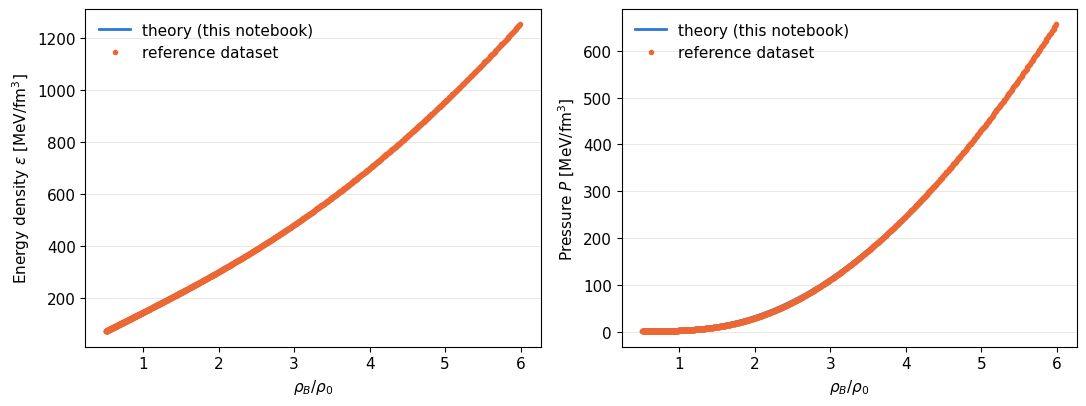

In [15]:

blue   = '#2a78d6'   # theory
orange = '#eb6834'   # reference

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(comp["rhoB/rho0"], comp["eps_theory"], color=blue, linewidth=2, label="theory (this notebook)")
axes[0].plot(comp["rhoB/rho0"], comp["eps_ref"], 'o', color=orange, markersize=3, label="reference dataset")
axes[0].set_xlabel(r'$\rho_B/\rho_0$'); axes[0].set_ylabel(r'Energy density $\varepsilon$ [MeV/fm$^3$]')
axes[0].legend(frameon=False)

axes[1].plot(comp["rhoB/rho0"], comp["P_theory"], color=blue, linewidth=2, label="theory (this notebook)")
axes[1].plot(comp["rhoB/rho0"], comp["P_ref"], 'o', color=orange, markersize=3, label="reference dataset")
axes[1].set_xlabel(r'$\rho_B/\rho_0$'); axes[1].set_ylabel(r'Pressure $P$ [MeV/fm$^3$]')
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(axis='y', color='#e9e8e1', linewidth=0.7)

plt.tight_layout(); plt.show()


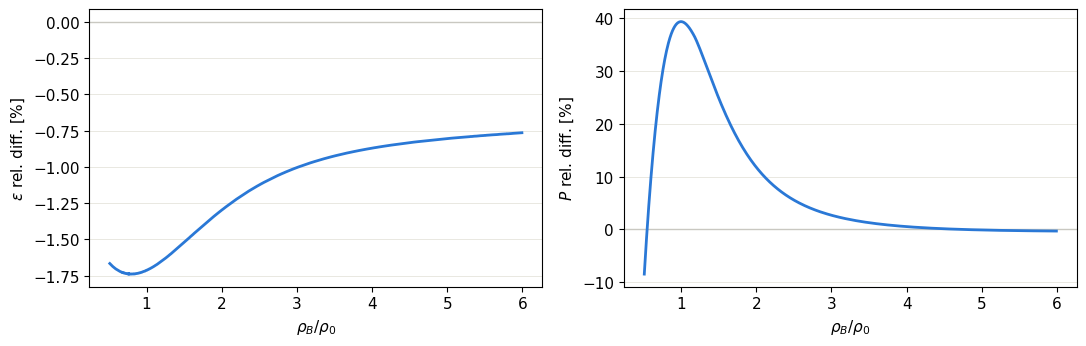

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].axhline(0, color='#c9c8c1', linewidth=1)
axes[0].plot(comp["rhoB/rho0"], comp["eps_reldiff_%"], color=blue, linewidth=2)
axes[0].set_xlabel(r'$\rho_B/\rho_0$'); axes[0].set_ylabel(r'$\varepsilon$ rel. diff. [%]')

axes[1].axhline(0, color='#c9c8c1', linewidth=1)
axes[1].plot(comp["rhoB/rho0"], comp["P_reldiff_%"], color=blue, linewidth=2)
axes[1].set_xlabel(r'$\rho_B/\rho_0$'); axes[1].set_ylabel(r'$P$ rel. diff. [%]')

for ax in axes:
    ax.grid(axis='y', color='#e9e8e1', linewidth=0.7)

plt.tight_layout(); plt.show()
